In [1]:
import pandas as pd
import numpy as np
import zipfile
from io import BytesIO
import requests
import io

In [2]:
# Load CIHI physician supply data from downloaded XLSX file
# Download from: https://www.cihi.ca/en/physicians
# File: "Supply, Distribution and Migration of Physicians in Canada, 2024"

try:
    filepath = '../data/supply-distribution-migration-physicians-in-canada-2024-data-tables-en.xlsx'
    df_physicians_original = pd.read_excel(filepath, sheet_name='Supply', header=2)

    df_physicians_original
except FileNotFoundError:
    print(f'FIle not found: {filepath}')
    print('Please download from: https://www.cihi.ca/en/physicians')
    print('Using synthetic data instead ...\n')

In [3]:
df_physicians_original.head()

,Year,Jurisdiction,Specialty,Number of physicians,Physician to population ratio,Number male,Number female,Number sex unknown,Average age,Number in Rural areas,...,Years since graduation: 11–25,Years since graduation: 26–30,Years since graduation: 31–35,Years since graduation: 36 and more,Number of physicians who returned from abroad,Number of physicians who moved abroad,Net migration between Canadian jurisdictions,Gain_count,Loss_count,Statistics Canada Population
0,2020,N.L.,Physician Supply,1361,258.311127,793,568,0,48.783664,327,...,560,141,125,262,1,1,-7,16,23,526884
1,2020,N.L.,Family Medicine,684,129.819846,383,301,0,48.346999,242,...,264,67,64,118,0,0,-8,6,14,526884
2,2020,N.L.,Specialists,677,128.491281,410,267,0,49.224852,85,...,296,74,61,144,1,1,1,10,9,526884
3,2020,N.L.,Clinical Specialists,451,0.000000,0,0,0,0.000000,0,...,0,0,0,0,0,0,0,0,0,0
4,2020,N.L.,Laboratory Specialists,35,0.000000,0,0,0,0.000000,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# see what columns are in this dataset

print('Statistics CIHI columns:')
print(df_physicians_original.columns)

Statistics CIHI columns:
Index(['Year', 'Jurisdiction', 'Specialty', 'Number of physicians',
       'Physician to population ratio', 'Number male', 'Number female',
       'Number sex unknown', 'Average age', 'Number in Rural areas',
       'Number in Urban areas', 'Place of MD Graduation: Canada',
       'Place of MD Graduation: Foreign',
       'Years since graduation: Fewer than 6', 'Years since graduation: 6–10',
       'Years since graduation: 11–25', 'Years since graduation: 26–30',
       'Years since graduation: 31–35', 'Years since graduation: 36 and more',
       'Number of physicians who returned from abroad',
       'Number of physicians who moved abroad',
       'Net migration between Canadian jurisdictions', 'Gain_count',
       'Loss_count', 'Statistics Canada Population'],
      dtype='object')


In [5]:
# see the data types 

df_physicians_original.dtypes

Year                                               int64
Jurisdiction                                      object
Specialty                                         object
Number of physicians                               int64
Physician to population ratio                    float64
Number male                                        int64
Number female                                      int64
Number sex unknown                                 int64
Average age                                      float64
Number in Rural areas                              int64
Number in Urban areas                              int64
Place of MD Graduation: Canada                     int64
Place of MD Graduation: Foreign                    int64
Years since graduation: Fewer than 6               int64
Years since graduation: 6–10                       int64
Years since graduation: 11–25                      int64
Years since graduation: 26–30                      int64
Years since graduation: 31–35  

In [6]:
# show # of male/female doctors out of total per year

# Aggregate by year first
yearly_data = df_physicians_original[df_physicians_original['Specialty'] == 'Family Medicine'].groupby('Year').agg({
    'Number of physicians': 'sum',
    'Number male': 'sum',
    'Number female': 'sum',
    'Number sex unknown': 'sum',
    'Number in Rural areas': 'sum',
    'Number in Urban areas': 'sum'
}).reset_index()

# Then calculate percentages
yearly_data['% male'] = 100 * yearly_data['Number male'] / yearly_data['Number of physicians']
yearly_data['% female'] = 100 * yearly_data['Number female'] / yearly_data['Number of physicians']

yearly_data['% unknown'] = 100 * yearly_data['Number sex unknown'] / yearly_data['Number of physicians']

yearly_data['% rural'] = 100 * yearly_data['Number in Rural areas'] / yearly_data['Number of physicians']
yearly_data['% urban'] = 100 * yearly_data['Number in Urban areas'] / yearly_data['Number of physicians']

yearly_data

,Year,Number of physicians,Number male,Number female,Number sex unknown,Number in Rural areas,Number in Urban areas,% male,% female,% unknown,% rural,% urban
0,2020,93594,48232,45360,2,11580,81818,51.533218,48.464645,0.002137,12.372588,87.417997
1,2021,94898,48302,46596,0,11760,82936,50.898860,49.101140,0.000000,12.392253,87.394887
2,2022,96584,48544,48038,2,11928,84466,50.260913,49.737016,0.002071,12.349872,87.453408
3,2023,96528,47876,48652,0,11990,84346,49.598044,50.401956,0.000000,12.421266,87.379828
4,2024,98376,48474,49902,0,12034,86148,49.274213,50.725787,0.000000,12.232658,87.570139


It appears that males dominate across all years. However, I noticed a downward trend where the percentage of male physicians has decreased over time compared to female physicians. The shift is subtle, though. Additionally, rural areas have the lowest percentage of family doctors.

In [7]:
# to see the age of physicians

# Aggregate by year first
yearly_data_graduation = df_physicians_original[df_physicians_original['Specialty'] == 'Family Medicine'].groupby('Year').agg({
    'Number of physicians': 'sum',
    'Years since graduation: 6–10': 'sum',
    'Years since graduation: 11–25': 'sum',
    'Years since graduation: 26–30': 'sum',
    'Years since graduation: 31–35': 'sum',
    'Years since graduation: 36 and more': 'sum'
}).reset_index()

yearly_data_graduation

,Year,Number of physicians,Years since graduation: 6–10,Years since graduation: 11–25,Years since graduation: 26–30,Years since graduation: 31–35,Years since graduation: 36 and more
0,2020,93594,14246,29878,10150,10090,17968
1,2021,94898,14798,30622,9876,10052,18534
2,2022,96584,15010,31856,9668,10054,18902
3,2023,96528,14318,32626,9336,9852,18812
4,2024,98376,13536,34328,9498,9690,19316


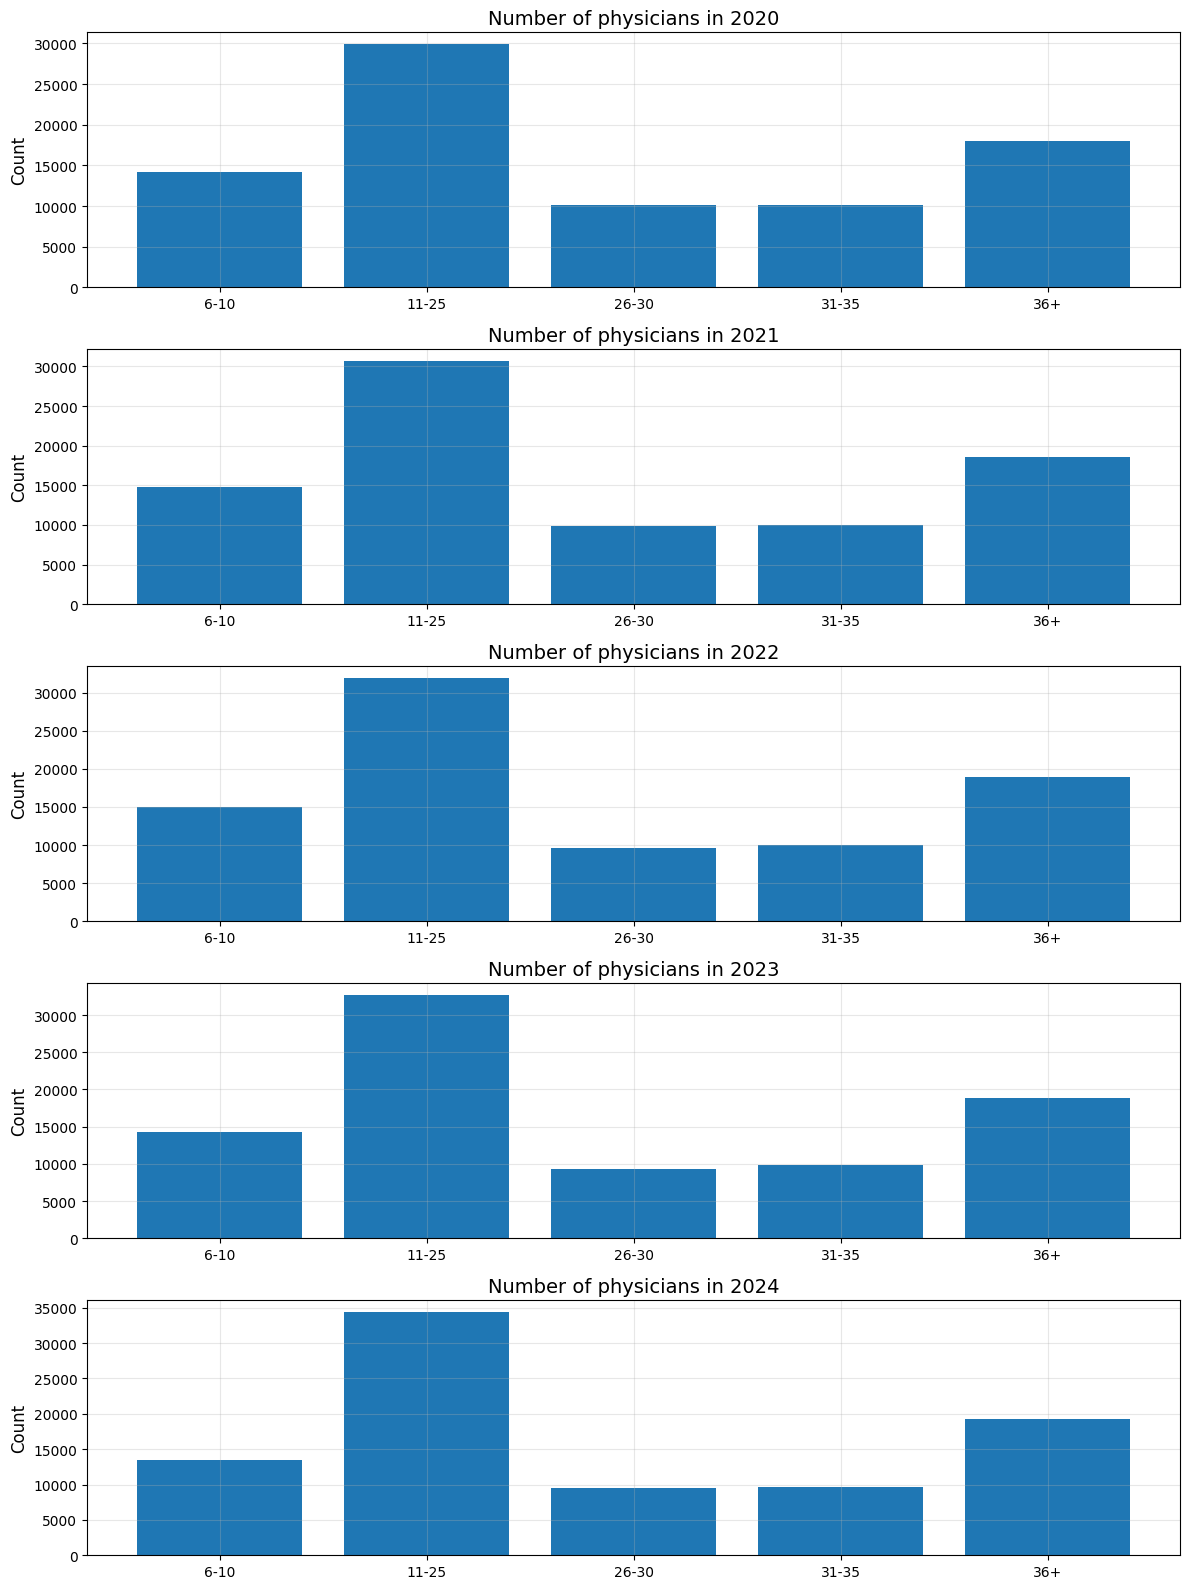

In [8]:
# display data for each graduation
import matplotlib.pyplot as plt

fix, axes = plt.subplots(5, 1, figsize=(12,16))

for idx, year in enumerate(yearly_data_graduation['Year']):
    # filter the data for each year before plotting
    year_data = yearly_data_graduation[yearly_data_graduation['Year'] == year]
    # accessing each plot by idx
    axes[idx].bar(['6-10', '11-25', '26-30', '31-35', '36+'],
                  [year_data['Years since graduation: 6–10'].values[0],
                  year_data['Years since graduation: 11–25'].values[0],
                   year_data['Years since graduation: 26–30'].values[0],
                   year_data['Years since graduation: 31–35'].values[0],
                   year_data['Years since graduation: 36 and more'].values[0]]
                  )
    axes[idx].set_title(f'Number of physicians in {year}', fontsize=14)
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The dominant group of family doctors throughout the years consists of those who graduated 11–25 years ago. Encouragingly, physicians who graduated in the last 6–10 years consistently number above 15,000 annually. While there was a slight decrease in the past two years, the numbers remain relatively stable.

In [9]:
# Display data coverage

# We noticed that a year column is int64

In [10]:
year_column = 'Year'

unique_year_ph = sorted(df_physicians_original[year_column].unique())

print(f'The CIHI Physician data covers: {unique_year_ph[0]}-{unique_year_ph[-1]}.\n')

print(f'Start year: {unique_year_ph[0]}')
print(f'End year: {unique_year_ph[-1]}\n')

print(f'Total years: {len(unique_year_ph)} years of data.')

The CIHI Physician data covers: 2020-2024.

Start year: 2020
End year: 2024

Total years: 5 years of data.


In [11]:
# Check data sizes

print('CIHI physician data shape:',df_physicians_original.shape)
print('Number of rows:', len(df_physicians_original))
print('Number of columns:', len(df_physicians_original.columns))

CIHI physician data shape: (490, 25)
Number of rows: 490
Number of columns: 25


In [12]:
# Display Summary

print("=" * 50)
print('DATA SUMMARY')
print("=" * 50)

# print("\n📊 Statistics Canada (Patient Satisfaction)")
# print(f"   Records: {len(df_satisfaction)}")
# print(f"   Columns: {len(df_satisfaction.columns)}")
# print(f"   Year range: {unique_years_stat[0]}-{unique_years_stat[-1]}")

print("\n🏥 CIHI (Physician Supply)")
print(f"   Records: {len(df_physicians_original)}")
print(f"   Columns: {len(df_physicians_original.columns)}")
print(f"   Year range: {unique_year_ph[0]}-{unique_year_ph[-1]}")

DATA SUMMARY

🏥 CIHI (Physician Supply)
   Records: 490
   Columns: 25
   Year range: 2020-2024


In [13]:
df_physicians_original['Year'] = pd.to_datetime(df_physicians_original['Year'], format='%Y')

In [14]:
df_physicians_original['Year']

0     2020-01-01
1     2020-01-01
2     2020-01-01
3     2020-01-01
4     2020-01-01
         ...    
485   2024-01-01
486   2024-01-01
487   2024-01-01
488   2024-01-01
489   2024-01-01
Name: Year, Length: 490, dtype: datetime64[ns]

In [15]:
df_physicians_original.dtypes

Year                                             datetime64[ns]
Jurisdiction                                             object
Specialty                                                object
Number of physicians                                      int64
Physician to population ratio                           float64
Number male                                               int64
Number female                                             int64
Number sex unknown                                        int64
Average age                                             float64
Number in Rural areas                                     int64
Number in Urban areas                                     int64
Place of MD Graduation: Canada                            int64
Place of MD Graduation: Foreign                           int64
Years since graduation: Fewer than 6                      int64
Years since graduation: 6–10                              int64
Years since graduation: 11–25           

In [16]:
unique_years = df_physicians_original['Year'].dt.year.unique()
print(f'The data starts from {unique_years[0]}-{unique_years[-1]}')

The data starts from 2020-2024


The next goal is to find how many doctors per 100k population. 

We have noticed that some columns like statistics Canada Population has zero values and missing data. 

Therefore, we want to check which rows have zero population.

In [17]:
print((df_physicians_original['Statistics Canada Population']==0).sum())

# Look at the empty rows
empty_rows = df_physicians_original[df_physicians_original['Statistics Canada Population'] == 0]
print(empty_rows['Specialty'].unique())

print(empty_rows[['Specialty', 'Statistics Canada Population']])

280
['Clinical Specialists' 'Laboratory Specialists' 'Surgical Specialists'
 'Medical Scientists']
                  Specialty  Statistics Canada Population
3      Clinical Specialists                             0
4    Laboratory Specialists                             0
5      Surgical Specialists                             0
6        Medical Scientists                             0
10     Clinical Specialists                             0
..                      ...                           ...
482      Medical Scientists                             0
486    Clinical Specialists                             0
487  Laboratory Specialists                             0
488    Surgical Specialists                             0
489      Medical Scientists                             0

[280 rows x 2 columns]


We have noticed that the four values in the column speciality have no values for the population. Therefore, before creating an additional column for calculation how many family doctors per 100k population, we will filter the data by removing the problematic specialities and leaving only the family medicine and all physicians. 

In [18]:
promlematic_values = ['Clinical Specialists', 'Laboratory Specialists', 'Surgical Specialists', 'Medical Scientists']

df_physicians = df_physicians_original[~df_physicians_original['Specialty'].isin(promlematic_values)].copy()


In [19]:
print(f'Row remaining: {len(df_physicians)}')

Row remaining: 210


In [20]:
df_grouped = df_physicians.groupby(['Year', 'Specialty']).agg({
    'Number of physicians': 'sum',
    'Statistics Canada Population': 'first'
}).reset_index()

df_grouped['Physicians_per_100k'] = (df_grouped['Number of physicians'] / 
                                        df_grouped['Statistics Canada Population']) * 100000

print(df_grouped[['Statistics Canada Population', 'Year', 'Specialty', 'Number of physicians']])

    Statistics Canada Population       Year         Specialty  \
0                         526884 2020-01-01   Family Medicine   
1                         526884 2020-01-01  Physician Supply   
2                         526884 2020-01-01       Specialists   
3                         527056 2021-01-01   Family Medicine   
4                         527056 2021-01-01  Physician Supply   
5                         527056 2021-01-01       Specialists   
6                         531308 2022-01-01   Family Medicine   
7                         531308 2022-01-01  Physician Supply   
8                         531308 2022-01-01       Specialists   
9                         538907 2023-01-01   Family Medicine   
10                        538907 2023-01-01  Physician Supply   
11                        538907 2023-01-01       Specialists   
12                        545247 2024-01-01   Family Medicine   
13                        545247 2024-01-01  Physician Supply   
14                       

In [21]:
print("=" * 50)
print('Prepare data for linear regression analysis')
print("=" * 50)
df_physicians['Physicians_per_100k'] = (df_physicians['Number of physicians'] / 
                                        df_physicians['Statistics Canada Population']) * 100000

# Family Physicians per 100k (only Family Medicine rows)
df_physicians['Family_Physicians_per_100k'] = 0  # Initialize

family_mask = df_physicians['Specialty'] == 'Family Medicine'
df_physicians.loc[family_mask, 'Family_Physicians_per_100k'] = (
    df_physicians.loc[family_mask, 'Number of physicians'] / 
    df_physicians.loc[family_mask, 'Statistics Canada Population']
) * 100000

# Rural Percentage
df_physicians['Rural_Percentage'] = (df_physicians['Number in Rural areas'] / 
                                     df_physicians['Number of physicians']) * 100


Prepare data for linear regression analysis


/var/folders/wy/v92nv28111j7vk4ynsyxm2700000gn/T/ipykernel_2797/118675012.py:11: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[129.81984649 109.9294567  137.99475923 136.83382859 129.78454806
 115.09427942 108.25051517 120.5256873  124.69668145 132.99585924
 169.21683588  89.87956139  53.1928367  123.05726016 131.8645457
 114.72063059 137.41264196 139.47865585 132.22087676 116.01828481
 108.1237194  116.46717381 122.37305798 136.18626792 165.26617164
  94.2147648   44.90345757 124.08255427 132.12675134 116.61772709
 131.28338777 138.89163487 132.00457871 115.02197114 111.14509178
 119.30875596 120.09097385 140.42033894 168.56492027 100.82000269
  61.79400351 124.02938632 123.58347544 118.01074186 121.06170834
 141.91470698 130.52637765 109.95181719 107.37291742 118.33223491
 116.38347116 137.66477515 164.96931571 102.95203778  61.42506143
 120.40869501 121.41286426 118.1741809  123.47009497 137.99884123

In [22]:
# Create a new column for retention rate

df_physicians['Physician_Retention_Rate'] = (1 - (
    (df_physicians['Number of physicians who moved abroad'] + df_physicians['Loss_count']) / 
    df_physicians['Number of physicians']
    )) * 100

print('\n' + '=' * 50)
print('Retention Rate')
print('=' * 50)
# print(df_physicians[['Year', 'Jurisdiction', 
#                      'Number of physicians',

#                      'Number of physicians who moved abroad', 
#                      'Loss_count','Physician_Retention_Rate']].head(15))


print(df_physicians[['Year', 'Specialty','Physician_Retention_Rate']]) 


Retention Rate
          Year         Specialty  Physician_Retention_Rate
0   2020-01-01  Physician Supply                 98.236591
1   2020-01-01   Family Medicine                 97.953216
2   2020-01-01       Specialists                 98.522895
7   2020-01-01  Physician Supply                 98.447205
8   2020-01-01   Family Medicine                 98.857143
..         ...               ...                       ...
477 2024-01-01   Family Medicine                 85.000000
478 2024-01-01       Specialists                100.000000
483 2024-01-01  Physician Supply                 99.890513
484 2024-01-01   Family Medicine                 99.918679
485 2024-01-01       Specialists                 99.863006

[210 rows x 3 columns]


In [23]:
# to replace the above abbreviations with full names of provinces/ territories

province_mapping = {
    'Alta.': 'Alberta',
    'B.C.': 'British Columbia',
    'Man.': 'Manitoba',
    'N.B.': 'New Brunswick',
    'N.L.': 'Newfoundland and Labrador',
    'N.S.': 'Nova Scotia',
    'N.W.T.': 'Northwest Territories',
    'Nun.': 'Nunavut',
    'Ont.': 'Ontario',
    'P.E.I.': 'Prince Edward Island',
    'Que.': 'Quebec',
    'Sask.': 'Saskatchewan',
    'Y.T.': 'Yukon',
    'Canada': 'Canada'
}

df_physicians['Jurisdiction'] = df_physicians['Jurisdiction'].map(province_mapping)


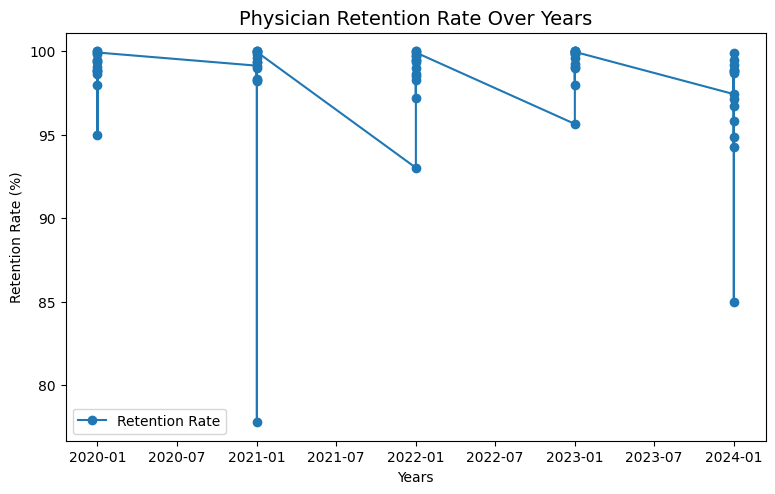

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_physicians is already defined
# Filter for Family doctors only
data = df_physicians[df_physicians['Specialty'] == 'Family Medicine']

# Prepare the DataFrame for the table
df_data = data[['Year','Physician_Retention_Rate']]
df_data.set_index('Year', inplace=True)

# Create a figure and axis for the plot
plt.figure(figsize=(10, 6))

# Create the line plot
plt.plot(df_data.index, df_data['Physician_Retention_Rate'], label='Retention Rate', marker='o')
plt.xlabel('Years')
plt.ylabel('Retention Rate (%)')
plt.title('Physician Retention Rate Over Years', fontsize=14)

plt.subplots_adjust(left=0.2, bottom=0.2)

plt.legend()
plt.show()


In [ ]:
# We identified provinces with physician retention rates below 90%. Based on the above plot, 
# this critical threshold was breached in 2021 and 2024, indicating periods of severe physician workforce instability.

result = data[data['Physician_Retention_Rate'] < 90][['Year', 'Jurisdiction','Specialty','Physician_Retention_Rate', 
                                                      'Family_Physicians_per_100k', 'Statistics Canada Population','Rural_Percentage', 'Number of physicians', 
                                                      'Number male', 'Number female']]

result

,Year,Jurisdiction,Specialty,Physician_Retention_Rate,Family_Physicians_per_100k,Statistics Canada Population,Rural_Percentage,Number of physicians,Number male,Number female
183,2021-01-01,Nunavut,Family Medicine,77.777778,44.903458,40086,100.0,18,10,8
477,2024-01-01,Nunavut,Family Medicine,85.000000,48.592045,41159,100.0,20,10,10


Nunavut stands out as the most critical case, with only 18-20 physicians serving a population of 40-41k residents. The physician retention rate in Nunavut drops to 77-85%—far below the national average of 99.9%—indicating severe workforce instability and unsustainable physician turnover.

In [25]:
print('\n' + '=' * 50)
print('Prepare data for ML model')
print('=' * 50)

# Aggregate by province and year
df_model_ph = df_physicians.groupby(['Year', 'Jurisdiction']).agg({
    'Physicians_per_100k': 'mean',
    'Family_Physicians_per_100k': 'sum',
    'Rural_Percentage': 'mean',
    'Physician_Retention_Rate': 'mean',
    'Average age': 'mean',
    'Statistics Canada Population': 'first'
}).reset_index()


print(f'Aggregated data: {df_model_ph.shape[0]}')
print(df_model_ph.head(5))


Prepare data for ML model
Aggregated data: 70
        Year      Jurisdiction  Physicians_per_100k  \
0 2020-01-01           Alberta           169.363021   
1 2020-01-01  British Columbia           168.376416   
2 2020-01-01            Canada           161.585242   
3 2020-01-01          Manitoba           144.285716   
4 2020-01-01     New Brunswick           165.851450   

   Family_Physicians_per_100k  Rural_Percentage  Physician_Retention_Rate  \
0                  124.696681          6.947296                 98.430416   
1                  132.995859          5.145122                 99.359826   
2                  123.057260          7.193740                 99.890060   
3                  108.250515         10.979125                 98.861689   
4                  136.833829         15.010705                 99.049482   

   Average age  Statistics Canada Population  
0    47.728251                       4407495  
1    48.881323                       5176101  
2    49.198124    

In [26]:
print('\n' + '=' * 50)
print('Create target variable')
print('=' * 50)

df_model_ph['No_Primary_Care_Percent'] = 100 - df_model_ph['Physician_Retention_Rate']

print('Target variable created.')


Create target variable
Target variable created.


In [27]:
print('\n' + '=' * 50)
print('Select features for linear regression')
print('=' * 50)

features = ['Family_Physicians_per_100k', 'Rural_Percentage', 'Physician_Retention_Rate']

target = 'No_Primary_Care_Percent'

# remove rows with missing values
df_model_clean = df_model_ph.dropna(subset=features + [target]).copy()

# remove rows with infinity values
df_model_clean = df_model_clean[~np.isinf(df_model_clean[features + [target]]).any(axis=1)]

# prepare X and y
X = df_model_clean[features].values
y = df_model_clean[target].values

print(f'Features (X): {features}')
print(f'Target (y): {target}')
print(f'Number of records: {len(X)}')


Select features for linear regression
Features (X): ['Family_Physicians_per_100k', 'Rural_Percentage', 'Physician_Retention_Rate']
Target (y): No_Primary_Care_Percent
Number of records: 70


In [28]:
df_model_clean['Jurisdiction'].unique().tolist()


['Alberta',
 'British Columbia',
 'Canada',
 'Manitoba',
 'New Brunswick',
 'Newfoundland and Labrador',
 'Northwest Territories',
 'Nova Scotia',
 'Nunavut',
 'Ontario',
 'Prince Edward Island',
 'Quebec',
 'Saskatchewan',
 'Yukon']

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [31]:
print('\n' + '=' * 50)
print('Standardize features')
print('=' * 50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Features standardized (scaled)')



Standardize features
Features standardized (scaled)


In [32]:
print("\n" + "=" * 60)
print("Train Linear Regression Model")
print("=" * 60)

model = LinearRegression()
model.fit(X_scaled, y)

# predictions
y_pred = model.predict(X_scaled)

# model evaluation

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print('Model performance:'+ '\n')
print(f'R2 score: {r2:.4f}')
print(f'RMSE: {rmse:.5f}%')


Train Linear Regression Model
Model performance:

R2 score: 1.0000
RMSE: 0.00000%


In [33]:
print("\n" + "=" * 60)
print("REGRESSION COEFFICIENTS (Standardized)")
print("=" * 60)
print(f"Family_Physicians_per_100k: {model.coef_[0]:.6f}")
print(f"Rural_Percentage: {model.coef_[1]:.4f}")
print(f"Retention_Rate_Percent: {model.coef_[2]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")


REGRESSION COEFFICIENTS (Standardized)
Family_Physicians_per_100k: -0.000000
Rural_Percentage: -0.0000
Retention_Rate_Percent: -2.3893
Intercept: 1.6922


In [34]:
print("\n" + "=" * 60)
print("PREDICTIONS BY PROVINCE AND YEAR")
print("=" * 60)

df_model_clean['Predicted_No_Primary_Care'] = y_pred
df_model_clean['Error'] = abs(df_model_clean[target] - df_model_clean['Predicted_No_Primary_Care'])

# Show predictions
for idx, row in df_model_clean.iterrows():
    print(f"\n{row['Jurisdiction']} ({str(row['Year'])}):")
    print(f"  Family_Physicians_per_100k: {row['Family_Physicians_per_100k']:.2f}")
    print(f"  Retention Rate: {row['Physician_Retention_Rate']:.1f}%")
    print(f"  Actual % without primary care: {row[target]:.1f}%")
    print(f"  Predicted % without primary care: {row['Predicted_No_Primary_Care']:.1f}%")
    print(f"  Error: {row['Error']:.1f}%")




PREDICTIONS BY PROVINCE AND YEAR

Alberta (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 124.70
  Retention Rate: 98.4%
  Actual % without primary care: 1.6%
  Predicted % without primary care: 1.6%
  Error: 0.0%

British Columbia (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 133.00
  Retention Rate: 99.4%
  Actual % without primary care: 0.6%
  Predicted % without primary care: 0.6%
  Error: 0.0%

Canada (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 123.06
  Retention Rate: 99.9%
  Actual % without primary care: 0.1%
  Predicted % without primary care: 0.1%
  Error: 0.0%

Manitoba (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 108.25
  Retention Rate: 98.9%
  Actual % without primary care: 1.1%
  Predicted % without primary care: 1.1%
  Error: 0.0%

New Brunswick (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 136.83
  Retention Rate: 99.0%
  Actual % without primary care: 1.0%
  Predicted % without primary care: 1.0%
  Error: 0.0%

Newfoundland and Lab


✓ Visualization saved as 'canada_primary_care_analysis.png'


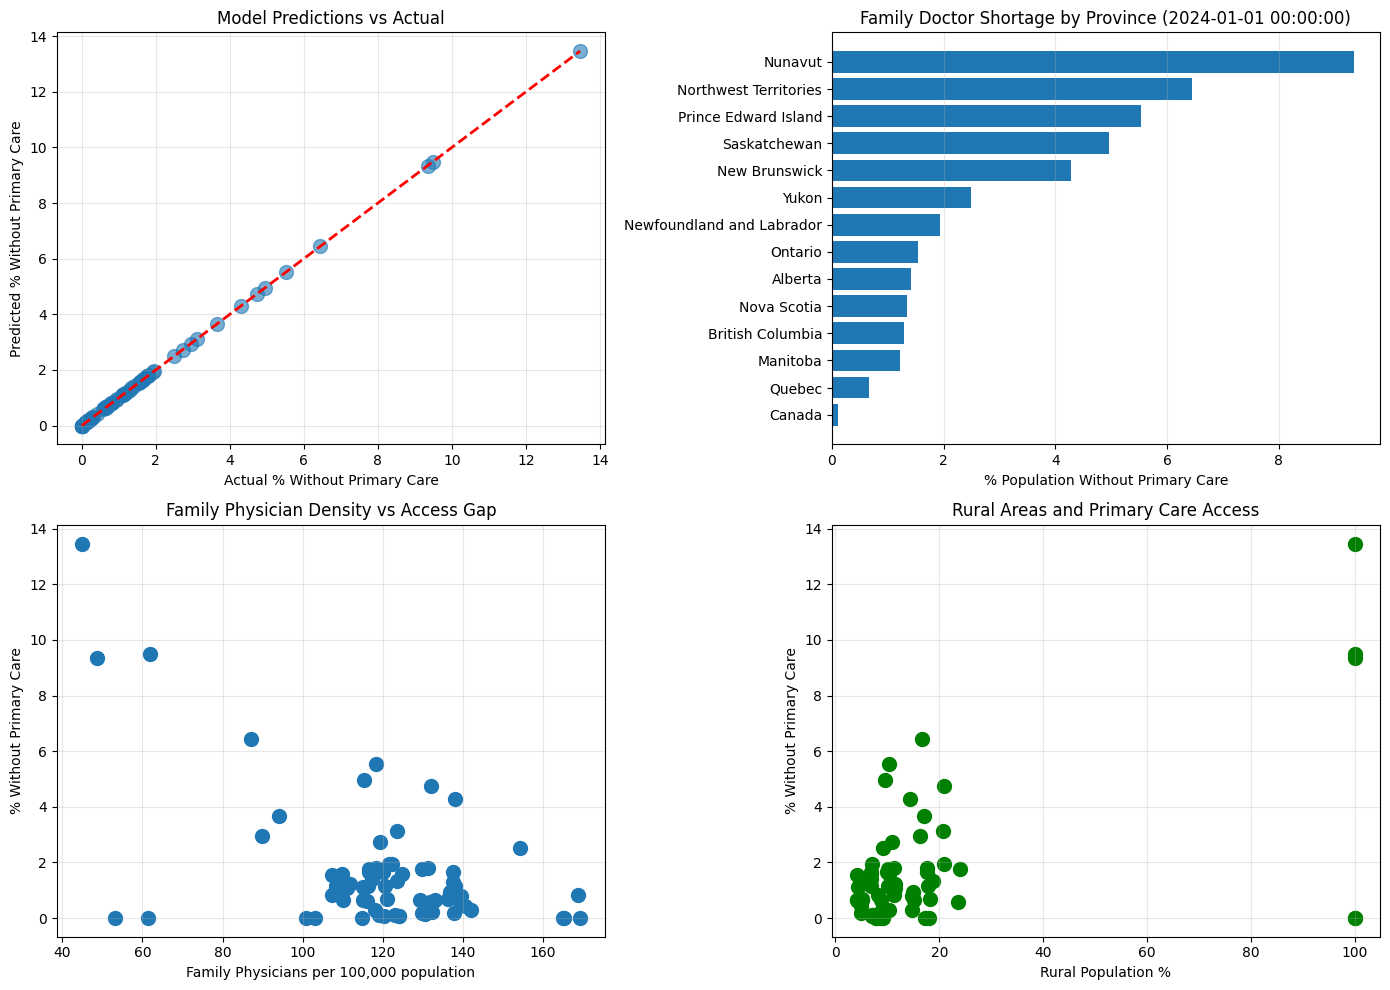

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(df_model_clean[target], df_model_clean['Predicted_No_Primary_Care'], alpha=0.6, s=100)
axes[0, 0].plot([df_model_clean[target].min(), df_model_clean[target].max()], 
                [df_model_clean[target].min(), df_model_clean[target].max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual % Without Primary Care')
axes[0, 0].set_ylabel('Predicted % Without Primary Care')
axes[0, 0].set_title('Model Predictions vs Actual')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Shortage by Province (latest year)
latest_year = df_model_clean['Year'].max()
df_latest = df_model_clean[df_model_clean['Year'] == latest_year].sort_values(target, ascending=True)
axes[0, 1].barh(df_latest['Jurisdiction'], df_latest[target])
axes[0, 1].set_xlabel('% Population Without Primary Care')
axes[0, 1].set_title(f'Family Doctor Shortage by Province ({str(latest_year)})')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Plot 3: Physicians per 100k vs Shortage
axes[1, 0].scatter(df_model_clean['Family_Physicians_per_100k'], df_model_clean[target], s=100)
axes[1, 0].set_xlabel('Family Physicians per 100,000 population')
axes[1, 0].set_ylabel('% Without Primary Care')
axes[1, 0].set_title('Family Physician Density vs Access Gap')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Rural % vs Shortage
axes[1, 1].scatter(df_model_clean['Rural_Percentage'], df_model_clean[target], s=100, color='green')
axes[1, 1].set_xlabel('Rural Population %')
axes[1, 1].set_ylabel('% Without Primary Care')
axes[1, 1].set_title('Rural Areas and Primary Care Access')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('canada_primary_care_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'canada_primary_care_analysis.png'")
plt.show()


1. The model predicts positively. Points are very closed to the line.
2. The analysis reveals significant geographic disparities in primary care access. Nunavut faces the most critical shortage (8% of population without primary care), followed by Northwest Territories (4-5%) and Prince Edward Island (3%). In contrast, Quebec and major urban centers have access rates below 0.5%.
3. To minimize primary care access gaps to below 2%, Canada should aim for at least 110-120 family physicians per 100,000 population. Currently, only the most well-resourced provinces meet this benchmark, while rural and remote territories fall significantly short, explaining the 5-8% access gaps in Nunavut and Northwest Territories.
    
    - Family Physicians per 100k → % Without Primary Care
    - 40-60                      → 6-8% (worst)
    - 80-100                     → 2-4% 
    - 110-140                    → 0.5-2% (acceptable)
    - 150+                       → 0-1% (very good)

    This benchmark aligns with CIHI and WHO standards for primary care adequacy. However, achieving 110-120 physicians per 100,000 in remote territories requires targeted recruitment and retention strategies, as these areas currently operate at 40-60 per 100,000 - a 50-66% shortfall from the target.

4. The fourth visualization reveals a strong correlation between rural population density and primary care access. Nunavut, with 60% rural population, experiences the worst access (6-8% without primary care). Conversely, provinces with primarily urban populations (0-20% rural) consistently achieve excellent access rates (0-2% without primary care). This suggests rurality is a critical barrier to primary care delivery in Canada. 

In [36]:
print("\nProvinces with lowest access (highest shortage):")
worst = df_model_clean.nlargest(3, target)[['Jurisdiction', 'Year', target]]
print(worst.to_string(index=False))

print("\nProvinces with best access (lowest shortage):")
best = df_model_clean.nsmallest(3, target)[['Jurisdiction', 'Year', target]]
print(best.to_string(index=False))


Provinces with lowest access (highest shortage):
Jurisdiction       Year  No_Primary_Care_Percent
     Nunavut 2021-01-01                13.468013
     Nunavut 2022-01-01                 9.482759
     Nunavut 2024-01-01                 9.347826

Provinces with best access (lowest shortage):
        Jurisdiction       Year  No_Primary_Care_Percent
             Nunavut 2020-01-01                      0.0
               Yukon 2020-01-01                      0.0
Prince Edward Island 2021-01-01                      0.0


In [37]:
! pip install xgboost

In [38]:
# XGboost model

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBRegressor

# X_train, Y_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [39]:
# fit model
model_xgboost = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)


model_xgboost.fit(X,y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [40]:
# evaluate model

y_pred = model_xgboost.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_squared_error(y, y_pred)

print('='* 50)
print('Model performace')
print('=' * 50)

print(f'R2 score: {r2:.4f}')
print(f'Prediction error, RMSE: {rmse:.4f}%')
print(f' On average, predictions are off by {rmse:.4f} percentage points')
print(f'MAE: {mae:.5f}%')
               

Model performace
R2 score: 1.0000
Prediction error, RMSE: 0.0089%
 On average, predictions are off by 0.0089 percentage points
MAE: 0.00008%


In [61]:
print("\n" + "=" * 60)
print("PREDICTIONS BY PROVINCE AND YEAR")
print("=" * 60)

target = 'No_Primary_Care_Percent'

df_model_clean['Predicted_No_Primary_Care'] = y_pred
df_model_clean['Error'] = abs(df_model_clean[target] - df_model_clean['Predicted_No_Primary_Care'])
df_model_clean['Error_Percent'] = (df_model_clean['Error']/ df_model_clean[target] * 100).round(2)

print('Sample predictions: ')
# Show predictions
for idx, row in df_model_clean.iterrows():
    print(f"\n{row['Jurisdiction']} ({str(row['Year'])}):")
    print(f"  Family_Physicians_per_100k: {row['Family_Physicians_per_100k']:.1f}")
    print(f"  Retention Rate: {row['Physician_Retention_Rate']:.1f}%")
    print(f"  Actual % without primary care: {row[target]:.1f}%")
    print(f"  Predicted % without primary care: {row['Predicted_No_Primary_Care']:.1f}%")
    print(f"  Error: {row['Error']:.1f}%")




PREDICTIONS BY PROVINCE AND YEAR
Sample predictions: 

Alberta (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 124.7
  Retention Rate: 98.4%
  Actual % without primary care: 1.6%
  Predicted % without primary care: 1.6%
  Error: 0.0%

British Columbia (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 133.0
  Retention Rate: 99.4%
  Actual % without primary care: 0.6%
  Predicted % without primary care: 0.6%
  Error: 0.0%

Canada (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 123.1
  Retention Rate: 99.9%
  Actual % without primary care: 0.1%
  Predicted % without primary care: 0.1%
  Error: 0.0%

Manitoba (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 108.3
  Retention Rate: 98.9%
  Actual % without primary care: 1.1%
  Predicted % without primary care: 1.1%
  Error: 0.0%

New Brunswick (2020-01-01 00:00:00):
  Family_Physicians_per_100k: 136.8
  Retention Rate: 99.0%
  Actual % without primary care: 1.0%
  Predicted % without primary care: 1.0%
  Error: 0.0%

Newf


Bar chart: actual vs predicted


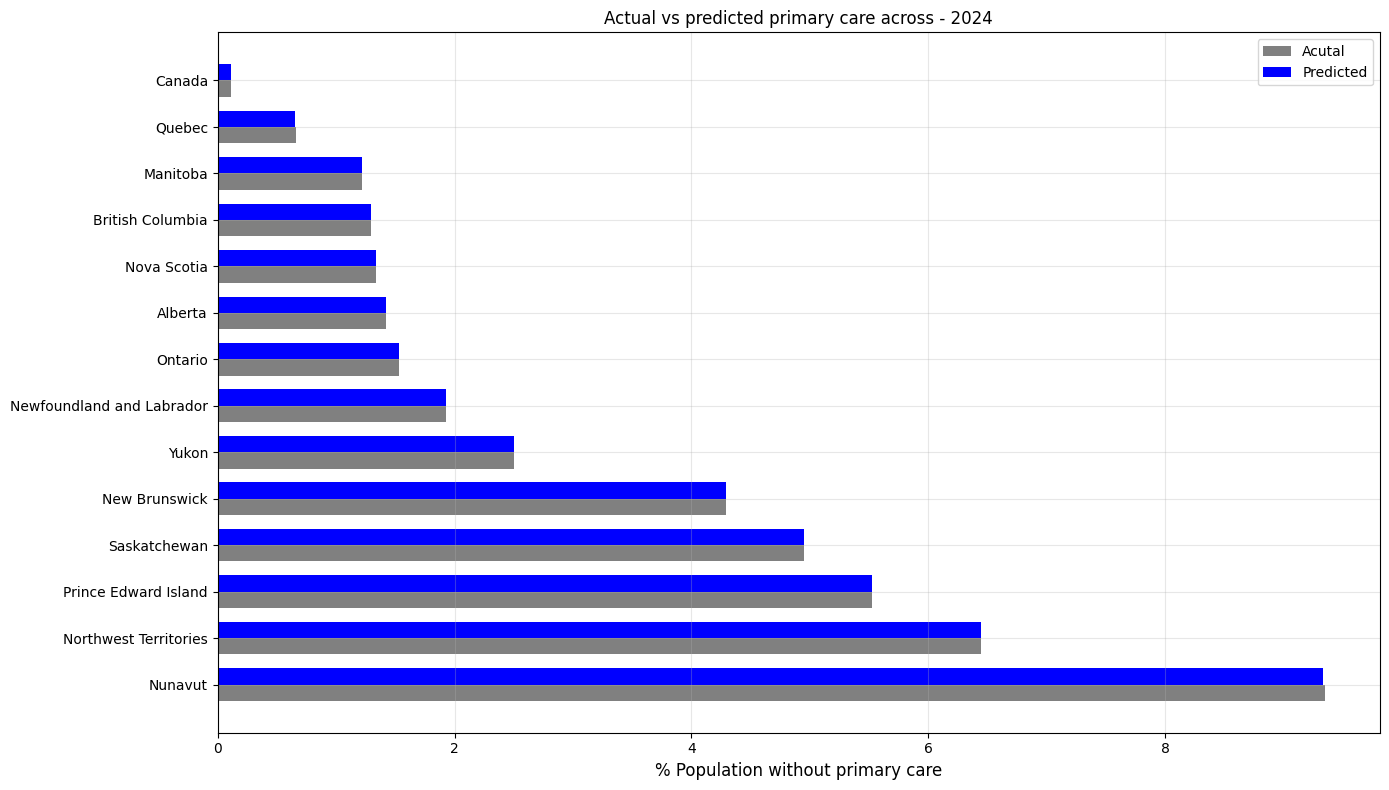

In [59]:
print('\n' + '=' * 50)
print('Bar chart: actual vs predicted')
print('=' * 50)

df_latest = df_model_clean[df_model_clean['Year']== latest_year].sort_values(target, ascending=False)

fig, ax = plt.subplots(figsize=(14,8))

x = range(len(df_latest))
width = 0.35

bars1 = ax.barh([i - width/2 for i in x], df_latest[target], width, label='Acutal', color='grey')
bars2 = ax.barh([i + width/2 for i in x], df_latest['Predicted_No_Primary_Care'], width, label='Predicted', color='blue')

ax.set_yticks(x)
ax.set_yticklabels(df_latest['Jurisdiction'])
ax.set_xlabel('% Population without primary care', fontsize=12)
ax.set_title(f'Actual vs predicted primary care across - {str(latest_year.year)}')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

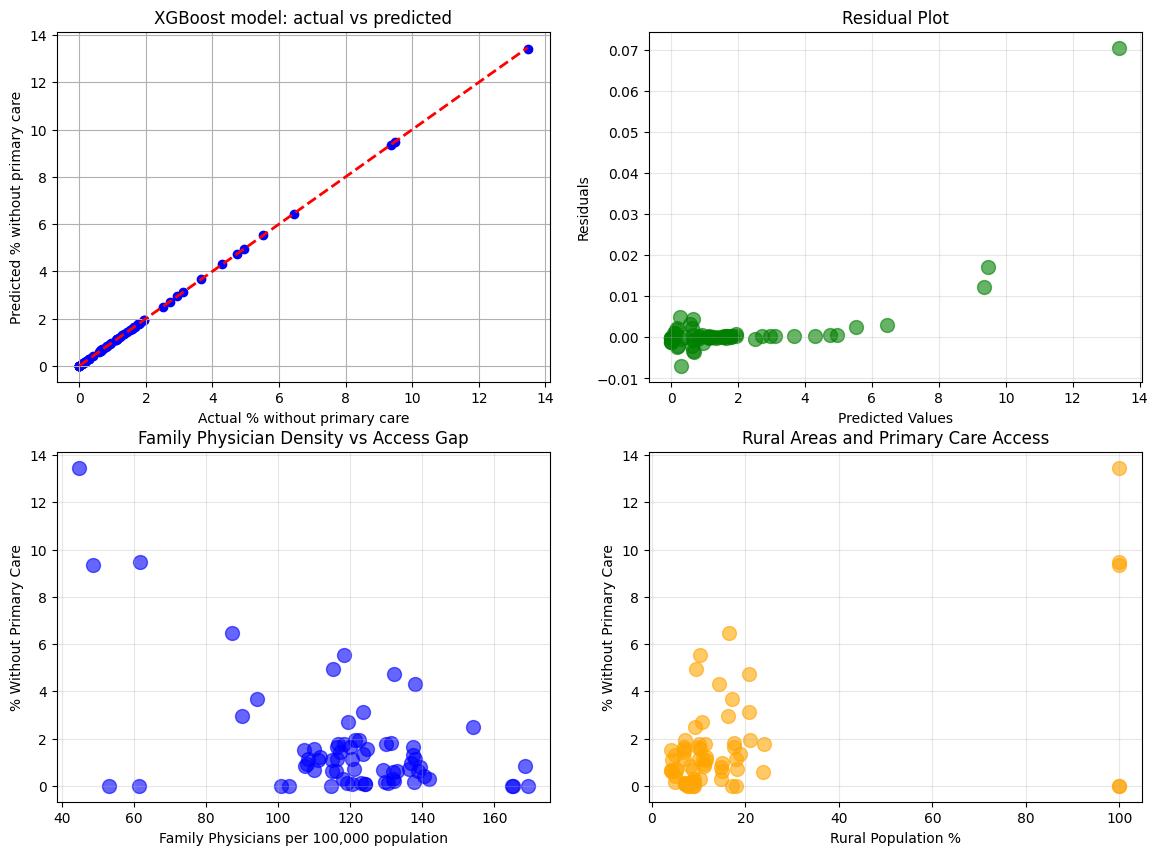

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# visualize actual vs predicted
axes[0, 0].scatter(df_model_clean[target], df_model_clean['Predicted_No_Primary_Care'], color='blue')
axes[0, 0].plot([df_model_clean[target].min(), df_model_clean[target].max()], 
                [df_model_clean[target].min(), df_model_clean[target].max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual % without primary care')
axes[0, 0].set_ylabel('Predicted % without primary care')
axes[0, 0].set_title(f'XGBoost model: actual vs predicted')
axes[0, 0].grid(True)

# to show errors
residuals = df_model_clean[target] - df_model_clean['Predicted_No_Primary_Care']
axes[0, 1].scatter(df_model_clean['Predicted_No_Primary_Care'], residuals, alpha=0.6, s=100, color='green')
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# to show physicians per 100k vs shortage
axes[1, 0].scatter(df_model_clean['Family_Physicians_per_100k'], df_model_clean[target], 
                   alpha=0.6, s=100, color='blue')
axes[1, 0].set_xlabel('Family Physicians per 100,000 population')
axes[1, 0].set_ylabel('% Without Primary Care')
axes[1, 0].set_title('Family Physician Density vs Access Gap')
axes[1, 0].grid(True, alpha=0.3)

#  Rural % vs Shortage
axes[1, 1].scatter(df_model_clean['Rural_Percentage'], df_model_clean[target], 
                   alpha=0.6, s=100, color='orange')
axes[1, 1].set_xlabel('Rural Population %')
axes[1, 1].set_ylabel('% Without Primary Care')
axes[1, 1].set_title('Rural Areas and Primary Care Access')
axes[1, 1].grid(True, alpha=0.3)

1. The XGBoost model demontrates excellent predictive accuracy.  
2. It shows how far off the predictions are. Mostly, all points are scattered around 0, which is good. We have a few of points off, but not too many. It seems like errors are random.
3. To achieve <1% primary care access gaps, Canada should target 140+ physicians per 100,000 population. However, physician supply alone is insufficient—geographic distribution matters equally. Even provinces with adequate physician numbers (120-140 per 100k) experience 2-3% access gaps if they have large rural populations. Therefore, Canada must implement a dual strategy: increase physician supply in underserved regions AND implement rural recruitment and retention programs to achieve universal access.
4. The fourth image shows a strong correlation between rural population percentage and primary care access. Areas with 60% rural population experience 5-8% of their population without primary care access. In contrast, when the rural population is below 10%, the primary care shortage is below 4%. 

In [44]:
print("\n✓ Provinces with WORST primary care access:")
worst = df_model_clean.nlargest(5, target)[['Jurisdiction', 'Year', target]]
for idx, row in worst.iterrows():
    print(f"  {row['Jurisdiction']} ({str(row['Year'])}): {row[target]:.4f}% without primary care")

print("\n✓ Provinces with BEST primary care access:")
best = df_model_clean.nsmallest(5, target)[['Jurisdiction', 'Year', target]]
for idx, row in best.iterrows():
    print(f"  {row['Jurisdiction']} ({str(row['Year'])}): {row[target]:.9f}% without primary care")



✓ Provinces with WORST primary care access:
  Nunavut (2021-01-01 00:00:00): 13.4680% without primary care
  Nunavut (2022-01-01 00:00:00): 9.4828% without primary care
  Nunavut (2024-01-01 00:00:00): 9.3478% without primary care
  Northwest Territories (2024-01-01 00:00:00): 6.4480% without primary care
  Prince Edward Island (2024-01-01 00:00:00): 5.5275% without primary care

✓ Provinces with BEST primary care access:
  Nunavut (2020-01-01 00:00:00): 0.000000000% without primary care
  Yukon (2020-01-01 00:00:00): 0.000000000% without primary care
  Prince Edward Island (2021-01-01 00:00:00): 0.000000000% without primary care
  Yukon (2021-01-01 00:00:00): 0.000000000% without primary care
  Northwest Territories (2022-01-01 00:00:00): 0.000000000% without primary care


It is interesting to note that Nunavut had good primary care access in 2020, but then it declined significantly over the following years and became the territory with the worst primary care access by 2024. This sharp deterioration suggests that physician retention or recruitment challenges have worsened considerably in recent years.

Despite being geographically isolated territories, Yukon and Prince Edward Island have  relatively better primary care access in 2020 and 2021 compared to Nunavut and the Northwest Territories. But then in 2024 Prince Edward Island have around 3% without primary care. 

This indicates that geographic remoteness alone does not determine primary care availability. Other factors—such as physician recruitment strategies, retention rates, and healthcare infrastructure—appear to play more important roles in ensuring access to family doctors.

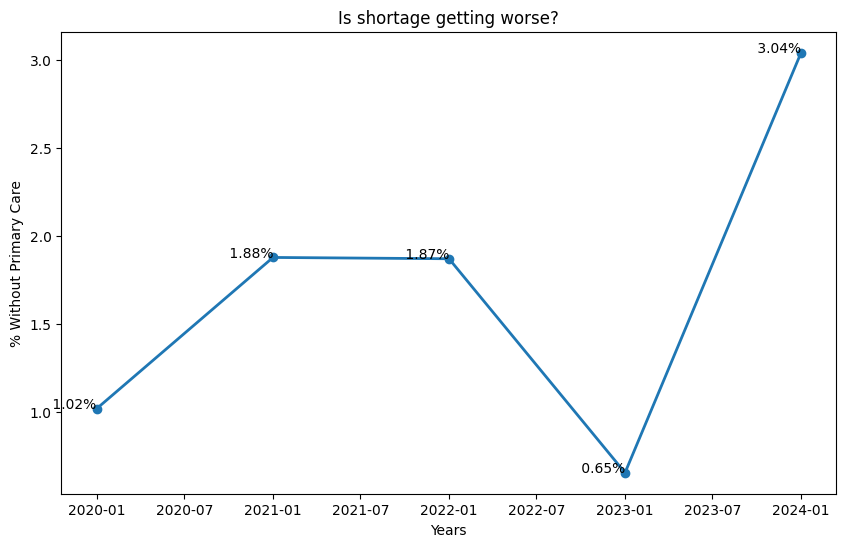

In [45]:
# Show the trend - is shortage getting worse?

access_by_year = df_model_clean.groupby('Year')['No_Primary_Care_Percent'].mean()

years = df_model_clean['Year']

plt.figure(figsize=(10, 6))

plt.plot(access_by_year.index, access_by_year.values, marker='o', linewidth=2)

for year, value in access_by_year.items():
    plt.text(year, value, f'{value: .2f}%', ha='right')

plt.title('Is shortage getting worse?')
plt.xlabel('Years')
plt.ylabel('% Without Primary Care')

plt.show()

Primary care access gaps remained stable from 2020-2023 (approximately 1.5%) but jumped dramatically to 3.04% in 2024 increase. This sudden worsening indicates a critical shift in Canada's healthcare landscape requiring immediate policy attention.

In [46]:
# Why are physicians leaving? We can check retention

retention_by_prov = df_model_clean.groupby('Jurisdiction')['Physician_Retention_Rate'].mean().sort_values()

print(retention_by_prov)

Jurisdiction
Nunavut                      93.540280
Northwest Territories        97.388817
Saskatchewan                 97.552137
Newfoundland and Labrador    97.574195
Prince Edward Island         98.167601
Alberta                      98.454037
New Brunswick                98.606951
Nova Scotia                  98.674328
Manitoba                     98.959413
Ontario                      99.093332
Yukon                        99.335004
British Columbia             99.355148
Quebec                       99.703715
Canada                       99.904194
Name: Physician_Retention_Rate, dtype: float64


Nunavut's physician retention rate of 93.5% is significantly lower than the national average of 99.96%. This means Nunavut loses approximately 6.36% of its physician workforce annually - compared to only 0.04% nationally. 

While Quebec retains 99.70% of its physicians, Nunavut retains only 93.54% - a 3.16% point difference. Over a 5-year period, Nunavut would lose appr. 31.8% of its physician workforce (6.36% annually x 5 years), compared to only 0.3% in Quebec.

In [47]:
# Average age by provinces
family_docs = df_physicians[df_physicians['Specialty'] == 'Family Medicine']
age_by_prov = family_docs.groupby('Jurisdiction')['Average age'].mean()

print(age_by_prov)

Jurisdiction
Alberta                      47.768898
British Columbia             48.975150
Canada                       49.209839
Manitoba                     48.078668
New Brunswick                50.390741
Newfoundland and Labrador    48.598039
Northwest Territories        49.238984
Nova Scotia                  49.784530
Nunavut                      46.061531
Ontario                      48.815130
Prince Edward Island         50.768607
Quebec                       51.087781
Saskatchewan                 48.532627
Yukon                        50.554236
Name: Average age, dtype: float64


While the national average physician age is 48.8 years, family physicians in remote ares (Nunavut, NWT) average 50+ years. Combined with low retention rates (93%), this aging workforce exacerbates the shortage. 

In [52]:
# Why do some provinces with adequate physicians still have access gaps?

high_density_low_access = df_model_clean[
    (df_model_clean['Family_Physicians_per_100k'] > 120) &
    (df_model_clean['No_Primary_Care_Percent'] > 2)
]

print(high_density_low_access[['Jurisdiction', 'Family_Physicians_per_100k', 'No_Primary_Care_Percent', 'Rural_Percentage']])

                 Jurisdiction  Family_Physicians_per_100k  \
33  Newfoundland and Labrador                  132.126751   
47  Newfoundland and Labrador                  123.583475   
60              New Brunswick                  137.998841   
69                      Yukon                  154.162384   

    No_Primary_Care_Percent  Rural_Percentage  
33                 4.746528         20.829502  
47                 3.112646         20.748994  
60                 4.289202         14.404530  
69                 2.500000          9.166667  


Increasing physician supply alone is insufficient. Newfoundland and Labrador has 132 physicians per 100k yet maintains 4.7% access gaps due to geographic dispersion. This suggests that distribution challenges are as critical as supply challenges. 

In [58]:
# What happens when provinces fall below the benchmark (< 100 per 100k)?

high_density_low_access = df_model_clean[
    (df_model_clean['Family_Physicians_per_100k'] < 100 )
]

print(high_density_low_access[['Jurisdiction', 'Family_Physicians_per_100k', 'No_Primary_Care_Percent', 'Rural_Percentage']])

             Jurisdiction  Family_Physicians_per_100k  \
6   Northwest Territories                   89.879561   
8                 Nunavut                   53.192837   
20  Northwest Territories                   94.214765   
22                Nunavut                   44.903458   
36                Nunavut                   61.794004   
50                Nunavut                   61.425061   
62  Northwest Territories                   87.187856   
64                Nunavut                   48.592045   

    No_Primary_Care_Percent  Rural_Percentage  
6                  2.948718         16.217949  
8                  0.000000        100.000000  
20                 3.659234         17.070979  
22                13.468013        100.000000  
36                 9.482759        100.000000  
50                 0.000000        100.000000  
62                 6.447964         16.591252  
64                 9.347826        100.000000  


Provinces with physician density below the 110 per 100,000 benchmark universally face primary care access gaps exceeding 3%. Notably, Nunavut and Northwest Territories both fall far below this threshold—Nunavut at 45-62 per 100k, Northwest Territories at 87-94 per 100k—resulting in access gaps of 6-13%. This confirms that the 110 per 100k benchmark is critical; falling below it predictably worsens access.